# Data pre-processing



In [ ]:
from google.colab import drive
drive.mount('/content/drive')
Dataset_Path = "/content/drive/MyDrive/Deep Learning Dataset "

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import os

data = []

for class_name in os.listdir(Dataset_Path):
    class_path = os.path.join(Dataset_Path, class_name)
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            data.append({
                "filename": os.path.join(class_path, img),
                "class": class_name
            })

df = pd.DataFrame(data)
print(df.head())
print("Total images:", len(df))

                                            filename     class
0  /content/drive/MyDrive/Deep Learning Dataset /...  Building
1  /content/drive/MyDrive/Deep Learning Dataset /...  Building
2  /content/drive/MyDrive/Deep Learning Dataset /...  Building
3  /content/drive/MyDrive/Deep Learning Dataset /...  Building
4  /content/drive/MyDrive/Deep Learning Dataset /...  Building
Total images: 2381


In [ ]:
for cls in os.listdir(Dataset_Path):
    print(cls, len(os.listdir(os.path.join(Dataset_Path, cls))))

Building 375
Car 534
Lab 448
Person 441
Tree 583


In [ ]:
print("Original dataset distribution:")
print(df['class'].value_counts())

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

print(f"\nTrain: {len(train_df)} samples")
print(f"Validation: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

print("\nTrain class distribution:")
print(train_df['class'].value_counts())
print("\nValidation class distribution:")
print(val_df['class'].value_counts())
print("\nTest class distribution:")
print(test_df['class'].value_counts())

Original dataset distribution:
class
Tree        583
Car         534
Lab         448
Person      441
Building    375
Name: count, dtype: int64

Train: 1666 samples
Validation: 357 samples
Test: 358 samples

Train class distribution:
class
Tree        408
Car         374
Lab         313
Person      309
Building    262
Name: count, dtype: int64

Validation class distribution:
class
Tree        87
Car         80
Lab         67
Person      66
Building    57
Name: count, dtype: int64

Test class distribution:
class
Tree        88
Car         80
Lab         68
Person      66
Building    56
Name: count, dtype: int64


In [ ]:
unique_classes = np.unique(train_df['class'])
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_df['class']
)

class_indices = {cls: idx for idx, cls in enumerate(unique_classes)}
class_weights_dict = {class_indices[cls]: weight for cls, weight in zip(unique_classes, class_weights)}
print("\nClass weights (calculated on training set only):", class_weights_dict)


Class weights (calculated on training set only): {0: np.float64(1.2717557251908398), 1: np.float64(0.8909090909090909), 2: np.float64(1.0645367412140576), 3: np.float64(1.07831715210356), 4: np.float64(0.8166666666666667)}


In [ ]:
import tensorflow as tf
import numpy as np
from typing import Optional, Tuple

def custom_preprocess(img: tf.Tensor) -> tf.Tensor:

    img = tf.cast(img, tf.float32)

    img = img / 255.0


    mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
    std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

    mean = tf.reshape(mean, [1, 1, 1, 3])
    std = tf.reshape(std, [1, 1, 1, 3])

    if len(img.shape) == 3:
        img = tf.expand_dims(img, axis=0)

    img = (img - mean) / std

    if img.shape[0] == 1 and len(img.shape) == 4:
        img = tf.squeeze(img, axis=0)

    return img


def compute_dataset_statistics(train_generator, sample_size: int = 1000) -> Tuple[np.ndarray, np.ndarray]:

    print("Computing dataset statistics from training data...")

    all_samples = []
    batch_count = 0
    max_batches = sample_size // train_generator.batch_size + 1

    train_generator.reset()

    for batch in train_generator:
        images, _ = batch
        all_samples.append(images)
        batch_count += 1

        if batch_count >= max_batches:
            break

    all_samples = np.concatenate(all_samples, axis=0)

    mean = np.mean(all_samples, axis=(0, 1, 2))  # Shape: (3,)
    std = np.std(all_samples, axis=(0, 1, 2))    # Shape: (3,)

    print(f"Computed mean: {mean}")
    print(f"Computed std: {std}")

    return mean, std


def create_advanced_preprocessor(use_dataset_stats: bool = False,
                               train_generator = None) -> callable:

    if use_dataset_stats:
        if train_generator is None:
            raise ValueError("train_generator is required when use_dataset_stats=True")

        mean, std = compute_dataset_statistics(train_generator)
        mean_tf = tf.constant(mean, dtype=tf.float32)
        std_tf = tf.constant(std, dtype=tf.float32)

        def preprocess_with_dataset_stats(img: tf.Tensor) -> tf.Tensor:
            img = tf.cast(img, tf.float32)
            img = img / 255.0

            mean_reshaped = tf.reshape(mean_tf, [1, 1, 1, 3])
            std_reshaped = tf.reshape(std_tf, [1, 1, 1, 3])

            if len(img.shape) == 3:
                img = tf.expand_dims(img, axis=0)

            img = (img - mean_reshaped) / std_reshaped

            if img.shape[0] == 1 and len(img.shape) == 4:
                img = tf.squeeze(img, axis=0)

            return img

        return preprocess_with_dataset_stats

    else:
        return custom_preprocessor


class CustomPreprocessor(tf.keras.layers.Layer):

    def __init__(self, use_imagenet_stats: bool = True, **kwargs):
        super().__init__(**kwargs)
        self.use_imagenet_stats = use_imagenet_stats

        if use_imagenet_stats:
            self.mean = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
            self.std = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)
        else:
            self.mean = tf.zeros(3, dtype=tf.float32)
            self.std = tf.ones(3, dtype=tf.float32)

    def set_statistics(self, mean: np.ndarray, std: np.ndarray):
        self.mean = tf.constant(mean, dtype=tf.float32)
        self.std = tf.constant(std, dtype=tf.float32)

    def call(self, inputs):
        x = tf.cast(inputs, tf.float32) / 255.0

        mean = tf.reshape(self.mean, [1, 1, 1, 3])
        std = tf.reshape(self.std, [1, 1, 1, 3])

        x = (x - mean) / std

        return x

    def get_config(self):
        config = super().get_config()
        config.update({
            'use_imagenet_stats': self.use_imagenet_stats,
            'mean': self.mean.numpy().tolist(),
            'std': self.std.numpy().tolist()
        })
        return config


def create_simple_preprocessor() -> tf.keras.Sequential:

    preprocessor = tf.keras.Sequential([
        tf.keras.layers.Rescaling(scale=1./255),

        tf.keras.layers.Normalization(
            mean=[0.485, 0.456, 0.406],
            variance=[0.229**2, 0.224**2, 0.225**2]
        )
    ])

    preprocessor.build(input_shape=(None, IMG_SIZE, IMG_SIZE, 3))

    return preprocessor


def test_preprocessor():
    print("Testing preprocessor functions...")

    dummy_img = tf.random.uniform((224, 224, 3), minval=0, maxval=255, dtype=tf.float32)

    print(f"\nOriginal image shape: {dummy_img.shape}")
    print(f"Original image range: [{tf.reduce_min(dummy_img):.1f}, {tf.reduce_max(dummy_img):.1f}]")

    processed = custom_preprocess(dummy_img)
    print(f"\nAfter custom_preprocess:")
    print(f"Shape: {processed.shape}")
    print(f"Range: [{tf.reduce_min(processed):.3f}, {tf.reduce_max(processed):.3f}]")
    print(f"Mean per channel: {tf.reduce_mean(processed, axis=[0, 1])}")
    print(f"Std per channel: {tf.math.reduce_std(processed, axis=[0, 1])}")

    preprocessor_layer = CustomPreprocessor(use_imagenet_stats=True)
    processed_layer = preprocessor_layer(tf.expand_dims(dummy_img, axis=0))
    print(f"\nAfter CustomPreprocessor layer:")
    print(f"Shape: {processed_layer.shape}")
    print(f"Range: [{tf.reduce_min(processed_layer):.3f}, {tf.reduce_max(processed_layer):.3f}]")

    return True


if __name__ == "__main__":
    test_preprocessor()


    print("\nPreprocessor functions are ready for use!")

Testing preprocessor functions...

Original image shape: (224, 224, 3)
Original image range: [0.0, 255.0]

After custom_preprocess:
Shape: (224, 224, 3)
Range: [-2.118, 2.640]
Mean per channel: [0.04957404 0.19507463 0.41958454]
Std per channel: [1.2637365 1.2849402 1.2796746]

After CustomPreprocessor layer:
Shape: (1, 224, 224, 3)
Range: [-2.118, 2.640]

Preprocessor functions are ready for use!


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocess,
    rotation_range=40,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.7, 1.3],
    fill_mode='reflect',
    validation_split=0.0
)

def custom_preprocess_with_aug(img):
    img = tf.cast(img, tf.float32) / 255.0

    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    mean = tf.reshape(mean, [1, 1, 1, 3])
    std = tf.reshape(std, [1, 1, 1, 3])

    img = (img - mean) / std

    return img

def create_advanced_train_datagen():
    return ImageDataGenerator(
        preprocessing_function=custom_preprocess_with_aug,
        rotation_range=40,
        width_shift_range=0.25,
        height_shift_range=0.25,
        shear_range=0.25,
        zoom_range=[0.8, 1.2],
        horizontal_flip=True,
        vertical_flip=False,
        brightness_range=[0.8, 1.2],
        # fill_mode='wrap',
        fill_mode='reflect',
        channel_shift_range=20.0,
        validation_split=0.0
    )


test_datagen = ImageDataGenerator(
    preprocessing_function=custom_preprocess_with_aug
)

train_datagen_corrected = create_advanced_train_datagen()

train_generator = train_datagen_corrected.flow_from_dataframe(
    dataframe=train_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42,
    interpolation='bilinear'
)

validation_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    interpolation='bilinear'
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filename',
    y_col='class',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    interpolation='bilinear'
)

print(f"\nClasses mapping: {train_generator.class_indices}")
print(f"Number of training batches: {len(train_generator)}")
print(f"Number of validation batches: {len(validation_generator)}")
print(f"Number of test batches: {len(test_generator)}")

def test_generators():
    print("\nTesting generators...")

    train_batch = next(train_generator)
    print(f"Training batch shape: {train_batch[0].shape}")
    print(f"Training labels shape: {train_batch[1].shape}")

    validation_generator.reset()
    val_batch = next(validation_generator)
    print(f"Validation batch shape: {val_batch[0].shape}")
    print(f"Validation labels shape: {val_batch[1].shape}")

    print(f"\nTraining image range: [{train_batch[0].min():.3f}, {train_batch[0].max():.3f}]")
    print(f"Validation image range: [{val_batch[0].min():.3f}, {val_batch[0].max():.3f}]")

    batch_labels = train_batch[1]
    class_counts = np.sum(batch_labels, axis=0)
    print(f"\nClass distribution in training batch: {class_counts}")

    return True


def visualize_augmentations(generator, num_images=4):
    import matplotlib.pyplot as plt

    generator.reset()
    images, labels = next(generator)

    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes = axes.ravel()

    class_names = list(generator.class_indices.keys())

    for i in range(min(num_images, len(images))):
        img = images[i]
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean  # Reverse normalization
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        label_idx = np.argmax(labels[i])
        axes[i].set_title(f"Class: {class_names[label_idx]}")
        axes[i].axis('off')

    plt.suptitle('Augmented Training Images', fontsize=16)
    plt.tight_layout()
    plt.show()


def get_class_weights(train_generator):
    from sklearn.utils.class_weight import compute_class_weight

    class_indices = train_generator.class_indices
    class_names = list(class_indices.keys())

    train_generator.reset()
    all_labels = []

    for i in range(len(train_generator)):
        _, labels = next(train_generator)
        label_indices = np.argmax(labels, axis=1)
        all_labels.extend(label_indices)

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(all_labels),
        y=all_labels
    )

    class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

    print(f"\nClass weights: {class_weights_dict}")
    for class_name, idx in class_indices.items():
        print(f"{class_name}: {class_weights_dict[idx]:.3f}")

    return class_weights_dict


Found 1285 validated image filenames belonging to 5 classes.
Found 282 validated image filenames belonging to 5 classes.
Found 283 validated image filenames belonging to 5 classes.

Classes mapping: {'Building': 0, 'Car': 1, 'Lab': 2, 'Person': 3, 'Tree': 4}
Number of training batches: 41
Number of validation batches: 9
Number of test batches: 9


In [ ]:
def build_improved_densenet_model(num_classes=5):

    base_model = DenseNet121(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        pooling=None
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)

    x = layers.Dense(512,
                    activation='relu',
                    kernel_regularizer=regularizers.l2(0.01),
                    bias_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.6)(x)

    x = layers.Dense(256,
                    activation='relu',
                    kernel_regularizer=regularizers.l2(0.01),
                    bias_regularizer=regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model, base_model

model, base_model = build_improved_densenet_model(num_classes=5)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()


callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1,
        min_delta=0.0001
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir='./logs',
        histogram_freq=1
    )
]

steps_per_epoch = max(1, len(train_df) // BATCH_SIZE)
validation_steps = max(1, len(val_df) // BATCH_SIZE)

print(f"Steps per epoch: {steps_per_epoch}")
print(f"Validation steps: {validation_steps}")


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,702,085 (29.38 MB)

 Trainable params: 660,997 (2.52 MB)

 Non-trainable params: 7,041,088 (26.86 MB)

Steps per epoch: 52
Validation steps: 11


In [ ]:
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
print("\n" + "="*60)
print("TRAINING MODEL")
print("="*60)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)



TRAINING MODEL
Epoch 1/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 3:11 17s/step - accuracy: 0.3048 - loss: 12.3757 - precision: 0.3276 - recall: 0.2368
Epoch 1: val_accuracy improved from -inf to 0.62057, saving model to best_model.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 953s 17s/step - accuracy: 0.3200 - loss: 12.2924 - precision: 0.3463 - recall: 0.2526 - val_accuracy: 0.6206 - val_loss: 10.9795 - val_precision: 0.9857 - val_recall: 0.2447 - learning_rate: 1.0000e-04
Epoch 2/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 2:04 11s/step - accuracy: 0.5480 - loss: 11.0586 - precision: 0.5995 - recall: 0.5030
Epoch 2: val_accuracy improved from 0.62057 to 0.81915, saving model to best_model.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 575s 11s/step - accuracy: 0.5600 - loss: 11.0049 - precision: 0.6113 - recall: 0.5151 - val_accuracy: 0.8191 - val_loss: 10.2027 - val_precision: 0.9396 - val_recall: 0.6064 - learning_rate: 1.0000e-04
Epoch 3/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 2:04 11s/step - accuracy: 0.7256 - loss: 10.2935 - precision: 0.7622 - recall: 0.6763
Epoch 3: val_accuracy improved from 0.81915 to 0.84752, saving model to best_model.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 565s 11s/step - accuracy: 0.7284 - loss: 10.2589 - precision: 0.7653 - recall: 0.6802 - val_accuracy: 0.8475 - val_loss: 9.6519 - val_precision: 0.9351 - val_recall: 0.7660 - learning_rate: 1.0000e-04
Epoch 4/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 2:01 11s/step - accuracy: 0.7976 - loss: 9.7616 - precision: 0.8241 - recall: 0.7519
Epoch 4: val_accuracy improved from 0.84752 to 0.90071, saving model to best_model.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 560s 11s/step - accuracy: 0.7963 - loss: 9.7410 - precision: 0.8231 - recall: 0.7525 - val_accuracy: 0.9007 - val_loss: 9.2228 - val_precision: 0.9360 - val_recall: 0.8298 - learning_rate: 1.0000e-04
Epoch 5/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 2:02 11s/step - accuracy: 0.8341 - loss: 9.3312 - precision: 0.8568 - recall: 0.8000
Epoch 5: val_accuracy improved from 0.90071 to 0.90426, saving model to best_model.h5


...

52/52 ━━━━━━━━━━━━━━━━━━━━ 539s 10s/step - accuracy: 0.9354 - loss: 6.3272 - precision: 0.9411 - recall: 0.9256 - val_accuracy: 0.9539 - val_loss: 6.1923 - val_precision: 0.9570 - val_recall: 0.9468 - learning_rate: 1.0000e-04
Epoch 23/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 2:00 11s/step - accuracy: 0.9347 - loss: 6.2050 - precision: 0.9419 - recall: 0.9272
Epoch 23: val_accuracy did not improve from 0.95390
52/52 ━━━━━━━━━━━━━━━━━━━━ 576s 11s/step - accuracy: 0.9360 - loss: 6.1988 - precision: 0.9432 - recall: 0.9284 - val_accuracy: 0.9539 - val_loss: 6.1004 - val_precision: 0.9570 - val_recall: 0.9468 - learning_rate: 1.0000e-04
Epoch 24/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 1:59 11s/step - accuracy: 0.9392 - loss: 6.1142 - precision: 0.9417 - recall: 0.9324
Epoch 24: val_accuracy did not improve from 0.95390
52/52 ━━━━━━━━━━━━━━━━━━━━ 554s 11s/step - accuracy: 0.9397 - loss: 6.1045 - precision: 0.9427 - recall: 0.9332 - val_accuracy: 0.9433 - val_loss: 6.0188 - val_precision: 0.9433 - val_recall: 0.

52/52 ━━━━━━━━━━━━━━━━━━━━ 557s 11s/step - accuracy: 0.9483 - loss: 5.7018 - precision: 0.9571 - recall: 0.9421 - val_accuracy: 0.9574 - val_loss: 5.6480 - val_precision: 0.9609 - val_recall: 0.9574 - learning_rate: 1.0000e-04
Epoch 29/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 1:57 11s/step - accuracy: 0.9491 - loss: 5.5996 - precision: 0.9534 - recall: 0.9453
Epoch 29: val_accuracy did not improve from 0.95745
52/52 ━━━━━━━━━━━━━━━━━━━━ 544s 10s/step - accuracy: 0.9456 - loss: 5.6050 - precision: 0.9505 - recall: 0.9417 - val_accuracy: 0.9574 - val_loss: 5.5584 - val_precision: 0.9609 - val_recall: 0.9574 - learning_rate: 1.0000e-04
Epoch 30/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 1:59 11s/step - accuracy: 0.9469 - loss: 5.5271 - precision: 0.9548 - recall: 0.9391
Epoch 30: val_accuracy did not improve from 0.95745
52/52 ━━━━━━━━━━━━━━━━━━━━ 570s 11s/step - accuracy: 0.9467 - loss: 5.5223 - precision: 0.9550 - recall: 0.9393 - val_accuracy: 0.9539 - val_loss: 5.4731 - val_precision: 0.9607 - val_recall: 0.

52/52 ━━━━━━━━━━━━━━━━━━━━ 560s 11s/step - accuracy: 0.9394 - loss: 5.4286 - precision: 0.9498 - recall: 0.9384 - val_accuracy: 0.9610 - val_loss: 5.3920 - val_precision: 0.9642 - val_recall: 0.9539 - learning_rate: 1.0000e-04
Epoch 32/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 1:56 11s/step - accuracy: 0.9432 - loss: 5.3734 - precision: 0.9523 - recall: 0.9350
Epoch 32: val_accuracy improved from 0.96099 to 0.96454, saving model to best_model.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 550s 10s/step - accuracy: 0.9444 - loss: 5.3677 - precision: 0.9530 - recall: 0.9360 - val_accuracy: 0.9645 - val_loss: 5.3110 - val_precision: 0.9644 - val_recall: 0.9610 - learning_rate: 1.0000e-04
Epoch 33/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 2:00 11s/step - accuracy: 0.9530 - loss: 5.2567 - precision: 0.9595 - recall: 0.9501
Epoch 33: val_accuracy improved from 0.96454 to 0.97163, saving model to best_model.h5


52/52 ━━━━━━━━━━━━━━━━━━━━ 556s 11s/step - accuracy: 0.9527 - loss: 5.2554 - precision: 0.9594 - recall: 0.9488 - val_accuracy: 0.9716 - val_loss: 5.2137 - val_precision: 0.9716 - val_recall: 0.9716 - learning_rate: 1.0000e-04
Epoch 34/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 1:58 11s/step - accuracy: 0.9636 - loss: 5.1848 - precision: 0.9674 - recall: 0.9586
Epoch 34: val_accuracy did not improve from 0.97163
52/52 ━━━━━━━━━━━━━━━━━━━━ 574s 10s/step - accuracy: 0.9614 - loss: 5.1872 - precision: 0.9652 - recall: 0.9563 - val_accuracy: 0.9681 - val_loss: 5.1408 - val_precision: 0.9681 - val_recall: 0.9681 - learning_rate: 1.0000e-04
Epoch 35/50
41/52 ━━━━━━━━━━━━━━━━━━━━ 2:00 11s/step - accuracy: 0.9633 - loss: 5.1167 - precision: 0.9647 - recall: 0.9580
Epoch 35: val_accuracy did not improve from 0.97163
52/52 ━━━━━━━━━━━━━━━━━━━━ 560s 11s/step - accuracy: 0.9645 - loss: 5.1062 - precision: 0.9658 - recall: 0.9592 - val_accuracy: 0.9645 - val_loss: 5.0584 - val_precision: 0.9645 - val_recall: 0.

In [ ]:
print("\n" + "="*60)
print("EVALUATION ON TEST SET")
print("="*60)

test_generator.reset()

test_results = model.evaluate(
    test_generator,
    steps=len(test_df) // BATCH_SIZE + 1,
    verbose=1
)

print(f"Test Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test Precision: {test_results[2]:.4f}")
print(f"Test Recall: {test_results[3]:.4f}")

test_f1 = 2 * (test_results[2] * test_results[3]) / (test_results[2] + test_results[3] + 1e-7)
print(f"Test F1-Score: {test_f1:.4f}")



EVALUATION ON TEST SET
12/12 ━━━━━━━━━━━━━━━━━━━━ 136s 11s/step - accuracy: 0.9714 - loss: 3.9578 - precision: 0.9714 - recall: 0.9714
Test Loss: 3.9892
Test Accuracy: 0.9717
Test Precision: 0.9717
Test Recall: 0.9717
Test F1-Score: 0.9717


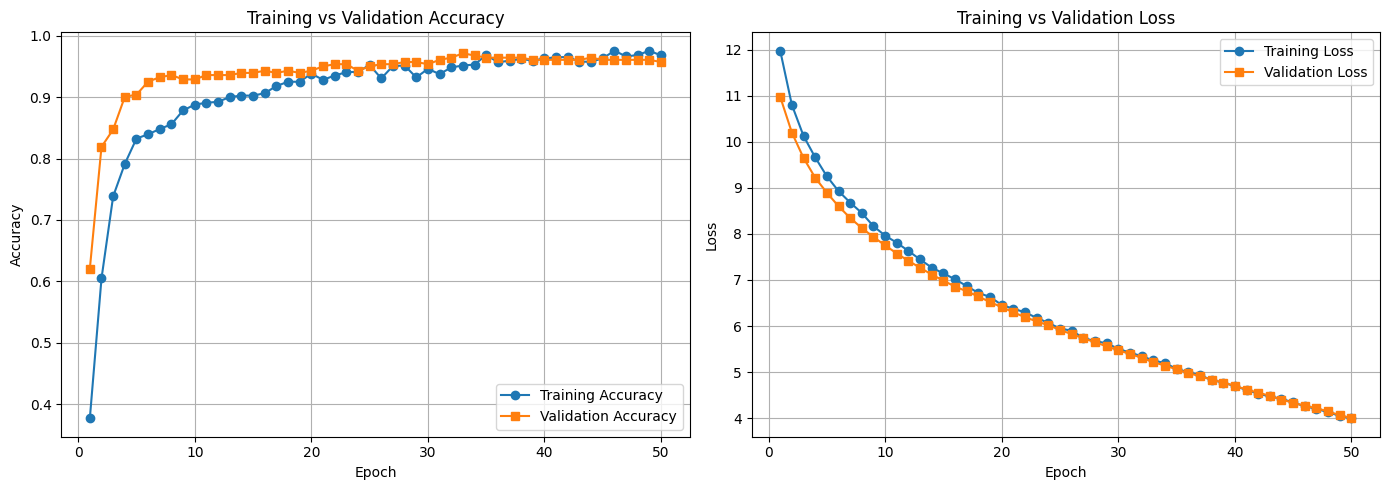

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, len(history.history['accuracy']) + 1)

plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(epochs, history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history.history['loss'], label='Training Loss', marker='o')
plt.plot(epochs, history.history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
plt.figure(figsize=(7, 5))




12/12 ━━━━━━━━━━━━━━━━━━━━ 113s 8s/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Building     0.9057    0.9600    0.9320        50
         Car     0.9846    1.0000    0.9922        64
         Lab     1.0000    1.0000    1.0000        38
      Person     1.0000    0.9592    0.9792        49
        Tree     0.9750    0.9512    0.9630        82

    accuracy                         0.9717       283
   macro avg     0.9731    0.9741    0.9733       283
weighted avg     0.9726    0.9717    0.9719       283



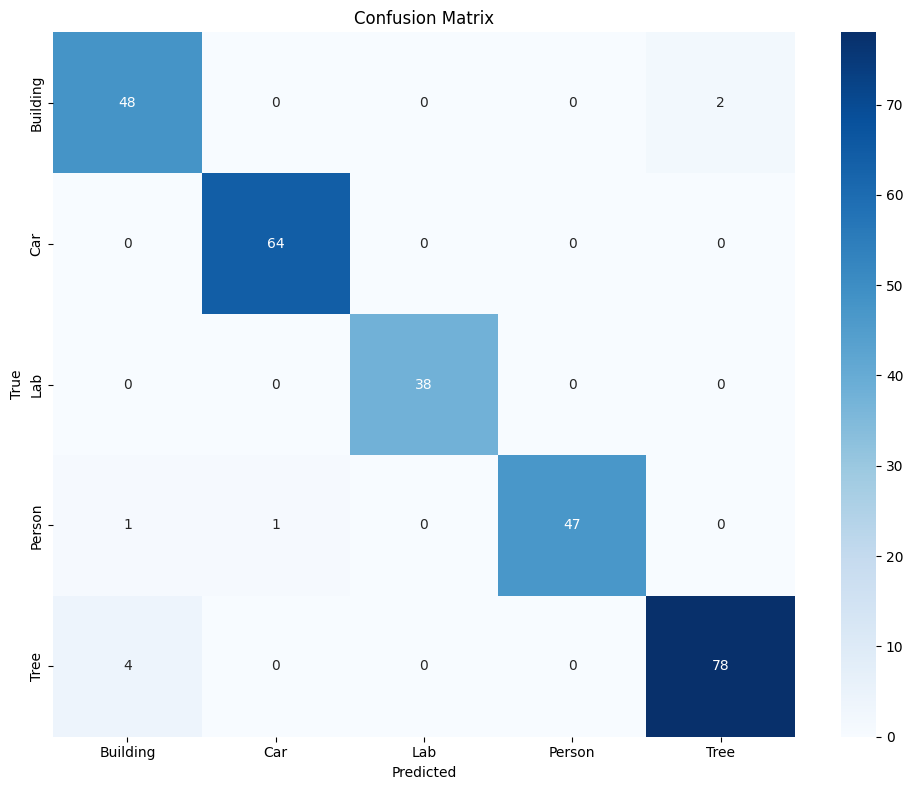


FINAL SUMMARY
Final Training Accuracy: 0.9681
Final Validation Accuracy: 0.9574
Test Accuracy: 0.9717
Train–Validation Accuracy Gap: 0.0106


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_generator.reset()
y_pred = model.predict(test_generator, steps=len(test_df) // BATCH_SIZE + 1)
y_pred_classes = np.argmax(y_pred, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(true_classes, y_pred_classes, target_names=class_labels, digits=4))

# Confusion Matrix
cm = confusion_matrix(true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()
print("\n" + "="*60)
print("FINAL SUMMARY")
print("="*60)

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")

acc_gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
print(f"Train–Validation Accuracy Gap: {acc_gap:.4f}")
